# PK parameter calibration

We calibrated the PK parameters of the model to data on the plasma concentrations of lecanemab after a single 10 mg/kg dose, the CSF:plasma ratio of lecanemab after a single 15 mg/kg dose, and an assumed brain:plasma ratio of 0.1%.

We assume that the PK parameters are consistent across anti-amyloid mAbs (excluding trontinemab which, likely as a result of its brainshuttle domain, shows faster plasma clearance).

This notebook details the data underlying our simplifying assumption of identical pharmacokinetics.

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# read in PK data on lecanemab, aducanumab and donanemab
df = pd.read_csv('Data/PK.csv')

In [3]:
# Prepare data for plotting
# Subset to select 10 mg/kg doses only
df_ten = df[df["Dose"] == "10 mg/kg"]
# Subset to select first month time points
df_short = df_ten[df_ten['time'] < 28*24]

### mAbs differ most in their terminal half-lives
Aducanumab has a noticibly longer terminal half-life in plasma. Looking at the initial clearance phase only, the concentration of drug at the two week and four week time points is similar. However, despite all being dosed at 10 mg/kg, the first recorded concentrations differ substantially.

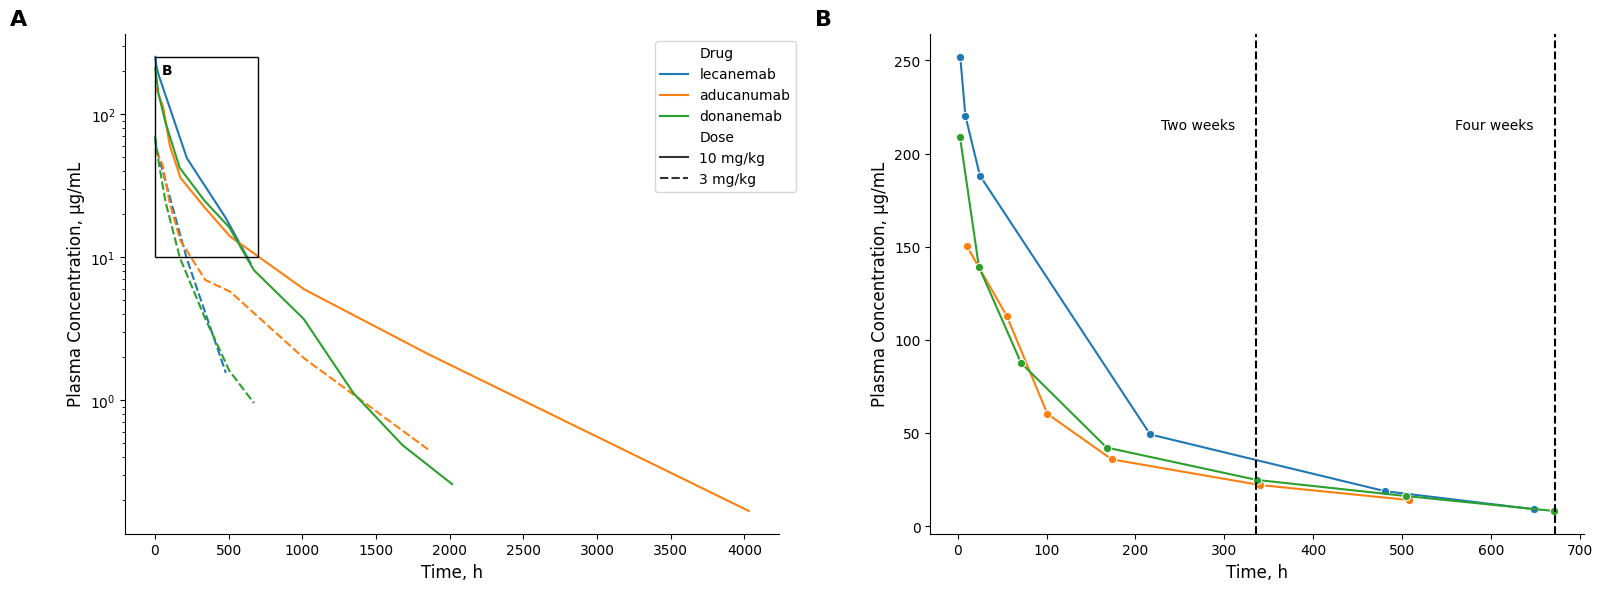

In [5]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: All three drugs, both doses, long time course
sns.lineplot(
    data=df,
    x="time",
    y="value",
    hue="Drug",
    style="Dose",
    dashes=True,
    palette="tab10",
    ax=axes[0]
)

# Panel B: Both doses, only first 4-week window and 10 mg/kg dose
sns.lineplot(
    data=df_short,
    x="time",
    y="value",
    hue="Drug",
    style="Dose",
    markers=True,
    dashes=False,
    palette="tab10",
    ax=axes[1]
)

# Style axes
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Label axes
axes[0].set_xlabel("Time, h", fontsize=12)
axes[0].set_ylabel("Plasma Concentration, μg/mL", fontsize=12)
axes[0].set_yscale('log')
axes[1].set_xlabel("Time, h", fontsize=12)
axes[1].set_ylabel("Plasma Concentration, μg/mL", fontsize=12)

# Draw box on A to indicate subplot B
y_max = df["value"].max()
axes[0].hlines(y=10, xmin=0, xmax=700, color='black', linestyle='-', linewidth=1)
axes[0].hlines(y=y_max, xmin=0, xmax=700, color='black', linestyle='-', linewidth=1)
axes[0].vlines(x=700, ymin=10, ymax=y_max, color='black', linestyle='-', linewidth=1)
axes[0].vlines(x=0, ymin=10, ymax=y_max, color='black', linestyle='-', linewidth=1)
axes[0].text(5*24, axes[0].get_ylim()[1]*0.5, 'B', color='black', fontweight="bold", rotation=0, va='bottom', ha='right', fontsize=10)

# Add vertical lines to B to indicate the 2-week and 4-week time points
axes[1].axvline(336, color='black', linestyle='dashed')
axes[1].axvline(28*24, color='black', linestyle='dashed')
axes[1].text(13*24, axes[1].get_ylim()[1]*0.8, 'Two weeks', color='black', rotation=0, va='bottom', ha='right', fontsize=10)
axes[1].text(27*24, axes[1].get_ylim()[1]*0.8, 'Four weeks', color='black', rotation=0, va='bottom', ha='right', fontsize=10)

axes[0].legend(bbox_to_anchor=(0.8, 1), loc='upper left')
axes[1].legend([],[], frameon=False)

# Label subplots A and B
axes[0].text(-0.15, 1.05, "A", transform=axes[0].transAxes, fontsize=16, fontweight="bold", va="top", ha="right")
axes[1].text(-0.15, 1.05, "B", transform=axes[1].transAxes, fontsize=16, fontweight="bold", va="top", ha="right")

plt.tight_layout()
plt.savefig('Plots/PK_profiles_paper.png', dpi=300)

We therefore directlty compared the half-lives of lecanemab, donanemab, and aducanumab by fitting exponential decay curves to each dataset.

In [6]:
don_10_df = df_short[df_short['Drug'] == 'donanemab']
adu_10_df = df_short[df_short['Drug'] == 'aducanumab']
lec_10_df = df_short[df_short['Drug'] == 'lecanemab']

In [7]:
# MW (molecular weight) is specific for each drug
MW = {
    "donanemab": 145089.74,     # g/mol (typical IgG1)
    "aducanumab": 145912.34,    # g/mol
    "lecanemab": 147181.62      # g/mol
}

def ugml_to_nM(ugml, drug):
    mw = MW.get(drug.lower())
    if mw is None:
        raise ValueError(f"No molecular weight provided for {drug}")
    return (ugml / mw) * 1e6

don_10_df['conc_nM'] = don_10_df['value'].apply(lambda x: ugml_to_nM(x, "donanemab"))
adu_10_df['conc_nM'] = adu_10_df['value'].apply(lambda x: ugml_to_nM(x, "aducanumab"))
lec_10_df['conc_nM'] = lec_10_df['value'].apply(lambda x: ugml_to_nM(x, "lecanemab"))

### After taking differences in initial concentrations into account (which may result, for example, from different average bodyweights), the half-lives span a range of approximately 28 days.

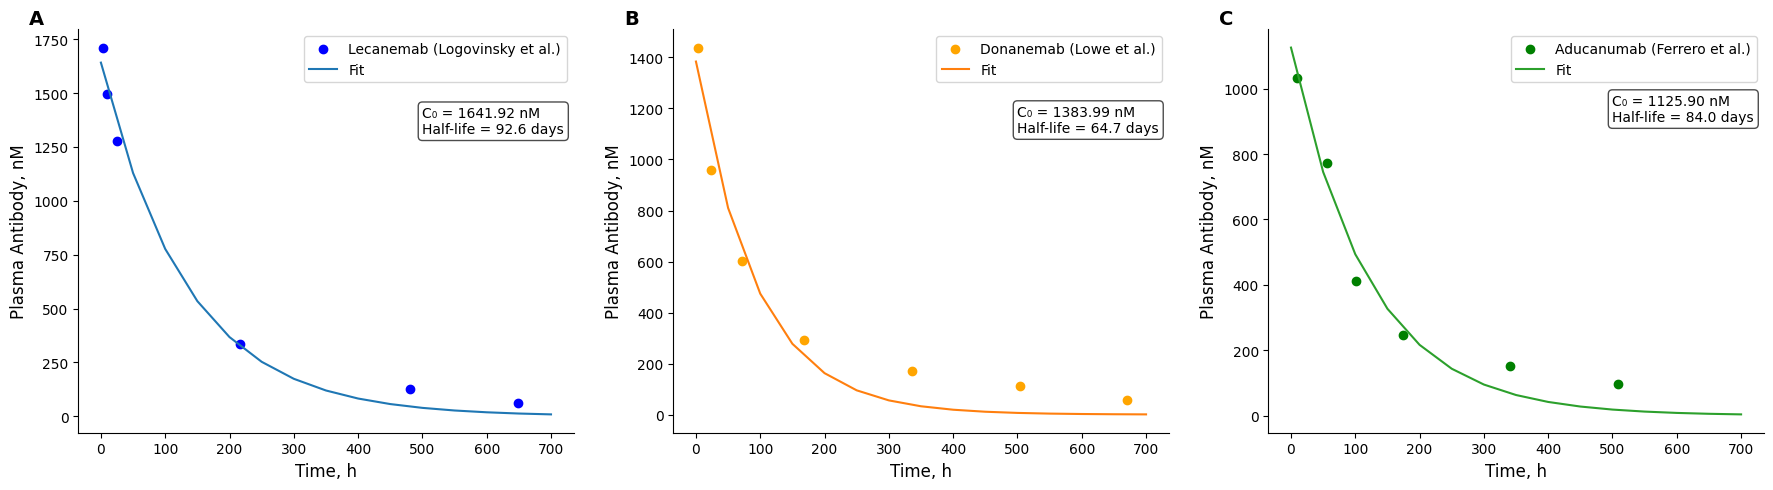

In [32]:
from scipy.optimize import curve_fit

# Define a simple function to fit, e.g., a mono-exponential decay function commonly used in PK modeling.
def mono_exp(x, A, k):
    return A * np.exp(-k * x)

# a) Fit to observed PK data
params_obs, cov_obs = curve_fit(mono_exp, np.array(lec_10_df['time']), np.array(lec_10_df['conc_nM']), [1750, 0.00385], maxfev=5000)
fit_y_obs = mono_exp(np.arange(0, 701, 50), *params_obs)

# b) Fit to simulated Donanemab PK data
params_don, cov_don = curve_fit(mono_exp, np.array(don_10_df['time']), np.array(don_10_df['conc_nM']), [1750, 0.00385], maxfev=5000)
fit_y_don = mono_exp(np.arange(0, 701, 50), *params_don)

params_adu, cov_adu = curve_fit(mono_exp, np.array(adu_10_df['time']), np.array(adu_10_df['conc_nM']), [1750, 0.00385], maxfev=5000)
fit_y_adu = mono_exp(np.arange(0, 701, 50), *params_adu)

# Optional: plot fits for verification
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.scatter(lec_10_df['time'], lec_10_df['conc_nM'], color='blue', label='Lecanemab (Logovinsky et al.)')
plt.plot(np.arange(0, 701, 50), fit_y_obs, color='tab:blue', label='Fit')
# Annotate plot with A (concentration at t=0) and half-life from k
plt.text(-0.1, 1.05, 'A', transform=plt.gca().transAxes,
         fontsize=14, fontweight='bold', va='top')
# Observed PK fit annotation
A_obs, k_obs = params_obs
half_life_obs = np.log(2) / k_obs
plt.annotate(
    f"C\u2080 = {A_obs:.2f} nM\nHalf-life = {half_life_obs:.1f} days",
    xy=(50, mono_exp(50, *params_obs)), xycoords='data',
    xytext=(500, A_obs * 0.8), textcoords='data',
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

#plt.title("Fit to Lecanemab Data")
plt.xlabel("Time, h", fontsize=12)
plt.ylabel("Plasma Antibody, nM", fontsize=12)
plt.legend()

plt.subplot(1,3,2)
plt.scatter(don_10_df['time'], don_10_df['conc_nM'], color='orange', label='Donanemab (Lowe et al.)')
plt.plot(np.arange(0, 701, 50), fit_y_don, color='tab:orange', label='Fit')

# Observed PK fit annotation
A_don, k_don = params_don
half_life_don = np.log(2) / k_don
plt.annotate(
    f"C\U00002080 = {A_don:.2f} nM\nHalf-life = {half_life_don:.1f} days",
    xy=(50, mono_exp(50, *params_don)), xycoords='data',
    xytext=(500, A_don * 0.8), textcoords='data',
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)
plt.text(-0.1, 1.05, 'B', transform=plt.gca().transAxes,
         fontsize=14, fontweight='bold', va='top')


#plt.title("Fit to Donanemab Data")
plt.xlabel("Time, h", fontsize=12)
plt.ylabel("Plasma Antibody, nM", fontsize=12)
plt.legend()

plt.subplot(1,3,3)
plt.scatter(adu_10_df['time'], adu_10_df['conc_nM'], color='green', label='Aducanumab (Ferrero et al.)')
plt.plot(np.arange(0, 701, 50), fit_y_adu, color='tab:green', label='Fit')

# Observed PK fit annotation
A_adu, k_adu = params_adu
half_life_adu = np.log(2) / k_adu
plt.annotate(
    f"C\U00002080 = {A_adu:.2f} nM\nHalf-life = {half_life_adu:.1f} days",
    xy=(50, mono_exp(50, *params_adu)), xycoords='data',
    xytext=(500, A_adu * 0.8), textcoords='data',
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)
plt.text(-0.1, 1.05, 'C', transform=plt.gca().transAxes,
         fontsize=14, fontweight='bold', va='top')


#plt.title("Fit to Donanemab Data")
plt.xlabel("Time, h", fontsize=12)
plt.ylabel("Plasma Antibody, nM", fontsize=12)
plt.legend()


for ax in plt.gcf().axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Plots/mono_exp_fit_lec_don_adu.png', dpi=300)
plt.show()